<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula15a%20-%20decision%20tree%20-%20continuos%20atributes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:,2:]
y = iris.target

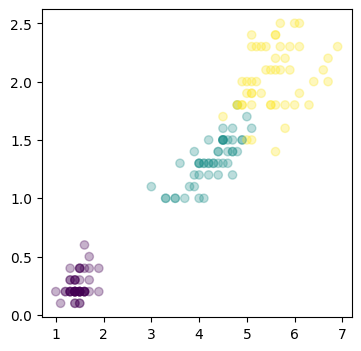

In [62]:
import matplotlib.pyplot as plt
import numpy as np

def plotDataset(X, y):
  plt.figure(figsize=(4, 4))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.3)

plotDataset(X, y)

plt.show()

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    shuffle=True,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [70]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from collections import Counter

def most_common(lst):
  data = Counter(lst)
  return data.most_common(1)[0][0]

class ZeroR(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
      self.answer = most_common(y)
      return self
    def predict(self, X):
      return [self.answer] * len(X)

model = ZeroR()
model.fit(X, y)
ypred = model.predict(X)
print(accuracy_score(y, ypred))

0.3333333333333333


In [71]:
model = ZeroR()
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))

0.3333333333333333


In [73]:
import numpy as np

# apenas uma característica
class DecisionTree(BaseEstimator, ClassifierMixin):
  def __init__(self, feature=0):
    self.feature = feature

  def fit(self, X, y):
    self.value = np.mean(X[:,self.feature])
    greater_values = X[:,self.feature] >= self.value
    if sum(greater_values)==0 or sum(~greater_values)==0:
      self.answer = most_common(y)
      self.n_samples = len(y)
    else:
      self.greaters = DecisionTree(self.feature).fit(X[greater_values],
                                                     y[greater_values])
      self.lessers = DecisionTree(self.feature).fit(X[~greater_values],
                                                    y[~greater_values])
    return self

  def predict(self, X):
    if hasattr(self, 'answer'):
      return np.array([self.answer] * len(X))
    else:
      greater_values = X[:,self.feature] >= self.value
    return np.where(greater_values,
                    self.greaters.predict(X),
                    self.lessers.predict(X))

model = DecisionTree()
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))

0.9


In [80]:
def print_tree(tree, depth=0):
  if hasattr(tree, 'answer'):
    print('\t' * depth, f"{depth} answer: {tree.answer} ({tree.n_samples})")
  else:
    print('\t' * depth, f"{depth} value: {tree.value}")
    print_tree(tree.greaters, depth+1)
    print_tree(tree.lessers, depth+1)

print_tree(model)

 0 value: 3.77
	 1 value: 5.013333333333333
		 2 value: 5.711764705882352
			 3 value: 6.214285714285715
				 4 value: 6.660000000000001
					 5 value: 6.766666666666667
						 6 answer: 2 (1)
						 6 answer: 2 (2)
					 5 value: 6.5
						 6 answer: 2 (1)
						 6 answer: 2 (1)
				 4 value: 5.966666666666666
					 5 value: 6.06
						 6 answer: 2 (3)
						 6 answer: 2 (2)
					 5 value: 5.85
						 6 answer: 2 (2)
						 6 answer: 2 (2)
			 3 value: 5.359999999999999
				 4 value: 5.57
					 5 value: 5.6499999999999995
						 6 answer: 2 (3)
						 6 answer: 2 (3)
					 5 value: 5.45
						 6 answer: 2 (2)
						 6 answer: 2 (2)
				 4 value: 5.15
					 5 value: 5.266666666666667
						 6 answer: 2 (2)
						 6 answer: 2 (1)
					 5 answer: 2 (7)
		 2 value: 4.434146341463415
			 3 value: 4.7285714285714295
				 4 value: 4.9
					 5 value: 4.942857142857143
						 6 answer: 2 (3)
						 6 answer: 1 (4)
					 5 answer: 1 (3)
				 4 value: 4.572727272727274
					 5 value: 4.66
						

In [81]:
def defineAxes(X):
    offset = 0.5
    min1, max1 = X[:, 0].min(), X[:, 0].max()
    min2, max2 = X[:, 1].min(), X[:, 1].max()
    return [min1-offset, max1+offset, min2-offset, max2+offset]

def plotPredictions(clf, X):
    axes = defineAxes(X)
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

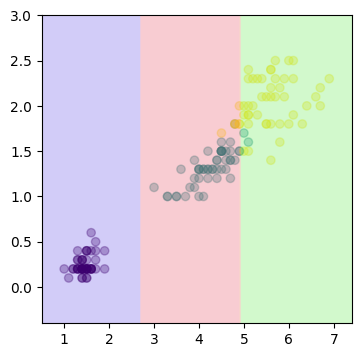

In [78]:
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

0.9333333333333333


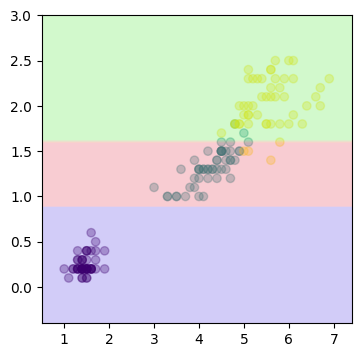

In [82]:
model = DecisionTree(1)
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))
plotDataset(X, y)
plotPredictions(model, X)
plt.show()

In [83]:
def gini(y):
  label = np.unique(y)
  aux = 0
  for l in label:
    p = np.sum(y==l)/len(y)
    aux += p**2
  return 1-aux

print(gini(y_train))

0.6666666666666667


In [85]:
def impurity_value(y, x, value, impurity_function=gini):
  greater_values = x >= value
  imp_greater = impurity_function(y[greater_values])
  imp_lessers = impurity_function(y[~greater_values])
  return len(y[greater_values])/len(y)*imp_greater + len(y[~greater_values])/len(y)*imp_lessers

print(impurity_value(y_train, X_train[:,0], 3.5))

0.34537408665225894


In [87]:
def best_split(y, x, impurity_function=gini):
  sx = np.sort(x)
  best_value = sx[0]
  best_impurity = 1
  for i in range(len(sx)-1):
    value = (sx[i-1]+sx[i])/2
    impurity = impurity_value(y, x, value, impurity_function)
    if impurity < best_impurity:
      best_impurity = impurity
      best_value = value
  return best_value, best_impurity

print(best_split(y_train, X_train[:,0]))

(np.float64(2.45), np.float64(0.3333333333333333))


In [94]:
def best_feature(y, X, impurity_function=gini):
  best_feature = 0
  best_value = 0
  best_impurity = 1
  for feature in range(X.shape[1]):
    value, impurity = best_split(y, X[:,feature], impurity_function)
    if impurity < best_impurity:
      best_impurity = impurity
      best_feature = feature
      best_value = value
  return best_feature, best_value, best_impurity

print(best_feature(y_train, X_train))

(0, np.float64(2.45), np.float64(0.3333333333333333))


In [95]:
class DecisionTree(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.feature, self.value, self.impurity = best_feature(y, X)
    greater_values = X[:,self.feature] >= self.value
    if sum(greater_values)==0 or sum(~greater_values)==0:
      self.answer = most_common(y)
      self.n_samples = len(y)
    else:
      self.greaters = DecisionTree().fit(X[greater_values],
                                         y[greater_values])
      self.lessers = DecisionTree().fit(X[~greater_values],
                                        y[~greater_values])
    return self

  def predict(self, X):
    if hasattr(self, 'answer'):
      return np.array([self.answer] * len(X))
    else:
      greater_values = X[:,self.feature] >= self.value
    return np.where(greater_values,
                    self.greaters.predict(X),
                    self.lessers.predict(X))

model = DecisionTree()
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))

0.9333333333333333


0.9333333333333333


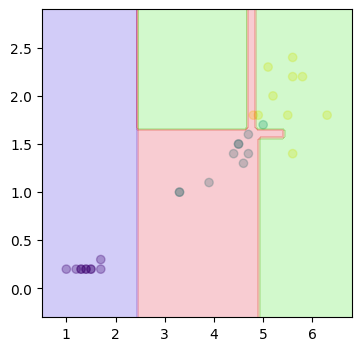

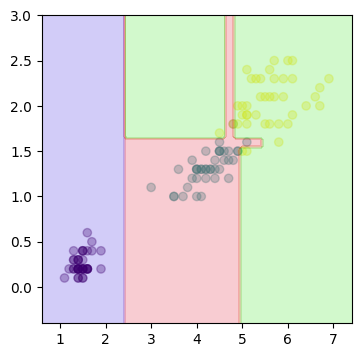

In [98]:
model = DecisionTree()
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotPredictions(model, X_test)
plt.show()
plotDataset(X_train, y_train)
plotPredictions(model, X_train)
plt.show()

In [99]:
print_tree(model)

 0 value: 2.45
	 1 value: 1.65
		 2 value: 4.85
			 3 value: 5.9
				 4 value: 6.4
					 5 value: 6.65
						 6 value: 6.800000000000001
							 7 answer: 2 (1)
							 7 answer: 2 (2)
						 6 value: 6.5
							 7 answer: 2 (1)
							 7 answer: 2 (1)
					 5 value: 6.0
						 6 value: 6.05
							 7 answer: 2 (3)
							 7 answer: 2 (2)
						 6 answer: 2 (2)
				 4 value: 5.35
					 5 value: 5.6
						 6 value: 5.699999999999999
							 7 value: 5.75
								 8 answer: 2 (1)
								 8 answer: 2 (3)
							 7 answer: 2 (3)
						 6 value: 5.45
							 7 answer: 2 (2)
							 7 answer: 2 (2)
					 5 value: 5.1
						 6 value: 5.199999999999999
							 7 value: 5.25
								 8 answer: 2 (2)
								 8 answer: 2 (1)
							 7 answer: 2 (5)
						 6 value: 4.95
							 7 answer: 2 (2)
							 7 answer: 2 (2)
			 3 value: 4.65
				 4 answer: 1 (2)
				 4 answer: 2 (1)
		 2 value: 4.95
			 3 value: 1.55
				 4 value: 5.449999999999999
					 5 answer: 2 (1)
					 5 answer: 1 (1)
				 4 val

In [115]:
class DecisionTree(BaseEstimator, ClassifierMixin):
  def __init__(self, max_depth=10, min_samples_split=2):
    self.max_depth = max_depth
    self.min_samples_split = min_samples_split
  def fit(self, X, y):
    self.feature, self.value, self.impurity = best_feature(y, X)
    greater_values = X[:,self.feature] >= self.value
    if sum(greater_values)>self.min_samples_split and \
       sum(~greater_values)>self.min_samples_split and \
       self.max_depth > 0:
      self.greaters = DecisionTree(max_depth=self.max_depth-1,
                                   min_samples_split=self.min_samples_split).fit(X[greater_values],
                                         y[greater_values])
      self.lessers = DecisionTree(max_depth=self.max_depth-1,
                                  min_samples_split=self.min_samples_split).fit(X[~greater_values],
                                        y[~greater_values])
    else:
      self.answer = most_common(y)
      self.n_samples = len(y)
    return self

  def predict(self, X):
    if hasattr(self, 'answer'):
      return np.array([self.answer] * len(X))
    else:
      greater_values = X[:,self.feature] >= self.value
    return np.where(greater_values,
                    self.greaters.predict(X),
                    self.lessers.predict(X))

model = DecisionTree(max_depth=10,min_samples_split=2)
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))

0.9666666666666667


0.9666666666666667


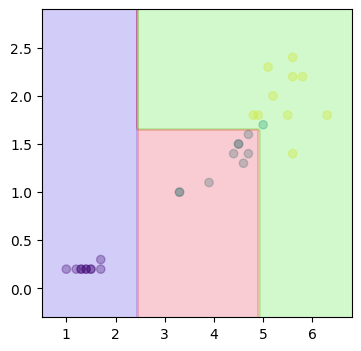

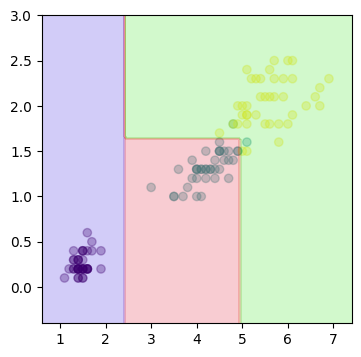

 0 value: 2.45
	 1 value: 1.65
		 2 answer: 2 (38)
		 2 value: 4.95
			 3 answer: 2 (4)
			 3 value: 3.95
				 4 value: 4.45
					 5 value: 4.7
						 6 answer: 1 (6)
						 6 answer: 1 (7)
					 5 value: 4.2
						 6 answer: 1 (9)
						 6 answer: 1 (8)
				 4 answer: 1 (8)
	 1 value: 1.5
		 2 value: 1.7
			 3 answer: 0 (4)
			 3 value: 1.55
				 4 answer: 0 (7)
				 4 answer: 0 (11)
		 2 answer: 0 (18)


In [120]:
model = DecisionTree(min_samples_split=3)
model.fit(X_train, y_train)
ypred = model.predict(X_test)
print(accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotPredictions(model, X_test)
plt.show()
plotDataset(X_train, y_train)
plotPredictions(model, X_train)
plt.show()
print_tree(model)

In [130]:
from sklearn.model_selection import cross_validate, KFold

model = DecisionTree(min_samples_split=3)
scores = cross_validate(model, X, y,
                        cv=KFold(shuffle=True))
print(scores['test_score'])
print(np.mean(scores['test_score']))

[0.93333333 0.9        1.         0.96666667 0.9       ]
0.9400000000000001
